# Chapter 9. Quantum Kernel & SVM

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 2**

## 학습 목표
- Quantum kernel을 회로로 직접 구현하기 (fidelity test)
- 커널 행렬을 scikit-learn SVM에 넣어 학습하기
- VQC와 정확도/속도 비교

In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

## 9.1 Iris 데이터 (이진 분류)
Iris-setosa vs Iris-versicolor 두 클래스를 사용한다.

In [2]:
data = load_iris()
X = data.data; y = data.target
# 클래스 0, 1만 선택
mask = y < 2
X, y = X[mask], y[mask]
# 셔플 후 30개만 사용 (커널 계산 시간 단축)
rng_idx = np.random.RandomState(0).permutation(len(X))[:30]
X, y = X[rng_idx], y[rng_idx]
# [0, π] 범위로 스케일링 - angle encoding에 적합
X = MinMaxScaler((0, np.pi)).fit_transform(X)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
print(f'학습: {X_tr.shape} (클래스 비율 {np.bincount(y_tr)}), 테스트: {X_te.shape}')

학습: (21, 4) (클래스 비율 [10 11]), 테스트: (9, 4)


## 9.2 양자 커널 정의
두 데이터 점 x, y에 대해 K(x, y) = |⟨φ(x)|φ(y)⟩|²을 회로로 계산한다.
회로 구조: U(x) - U(y)† 적용 후 |0⟩에서 측정될 확률

In [3]:
n_qubits = 4
dev = qml.device('default.qubit', wires=n_qubits)

def feature_map(x, wires):
    # 단순 angle encoding을 두 번 (re-uploading)
    qml.AngleEmbedding(x, wires=wires, rotation='Y')
    # 인접 큐비트 얽힘 (ring 패턴)
    for i in range(len(wires)):
        qml.CNOT(wires=[wires[i], wires[(i + 1) % len(wires)]])
    qml.AngleEmbedding(x, wires=wires, rotation='Z')

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    feature_map(x1, wires=range(n_qubits))
    # 두번째 데이터의 인코딩을 역으로 적용 (adjoint)
    qml.adjoint(feature_map)(x2, wires=range(n_qubits))
    # |0...0> 측정 확률이 곧 fidelity
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(x1, x2):
    return kernel_circuit(x1, x2)[0]

print(f'K(x_1, x_1) = {quantum_kernel(X_tr[0], X_tr[0]):.4f}  (자기 자신: 1)')
print(f'K(x_1, x_2) = {quantum_kernel(X_tr[0], X_tr[1]):.4f}')

K(x_1, x_1) = 1.0000  (자기 자신: 1)
K(x_1, x_2) = 0.0001


## 9.3 커널 행렬 계산
학습 데이터 전체에 대해 N×N 커널 행렬을 만든다.

In [4]:
def kernel_matrix(A, B):
    # A x B의 모든 쌍에 대해 커널 값 계산
    return np.array([[quantum_kernel(a, b) for b in B] for a in A])

K_train = kernel_matrix(X_tr, X_tr)
K_test = kernel_matrix(X_te, X_tr)
print(f'K_train shape: {K_train.shape}')
print(f'대각 원소 평균: {np.diag(K_train).mean():.3f}  (이론값 1)')

K_train shape: (21, 21)
대각 원소 평균: 1.000  (이론값 1)


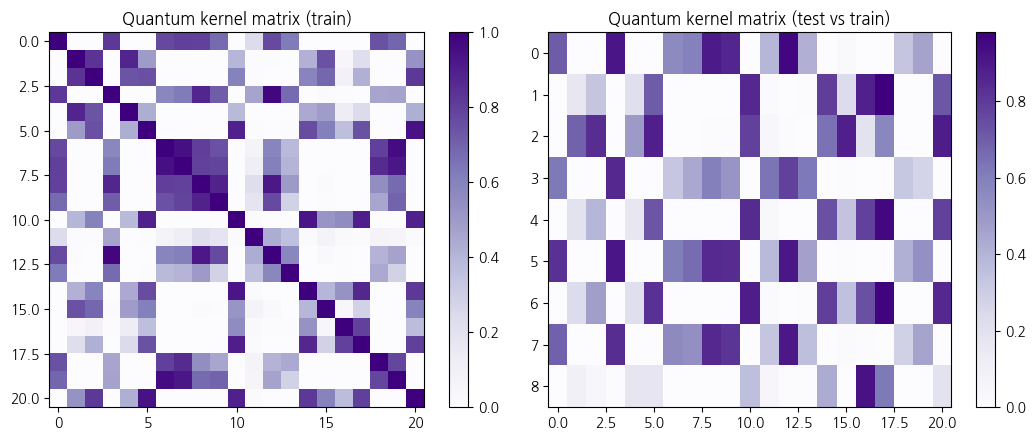

In [5]:
# 커널 행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im1 = axes[0].imshow(K_train, cmap='Purples')
axes[0].set_title('Quantum kernel matrix (train)')
plt.colorbar(im1, ax=axes[0])
im2 = axes[1].imshow(K_test, cmap='Purples', aspect='auto')
axes[1].set_title('Quantum kernel matrix (test vs train)')
plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

## 9.4 SVM에 양자 커널 주입
scikit-learn SVM은 `kernel='precomputed'`로 미리 계산된 커널 행렬을 받을 수 있다.

In [6]:
svm = SVC(kernel='precomputed')
svm.fit(K_train, y_tr)

acc_tr = svm.score(K_train, y_tr)
acc_te = svm.score(K_test, y_te)
print(f'학습 정확도:   {acc_tr:.3f}')
print(f'테스트 정확도: {acc_te:.3f}')

# 비교: 같은 데이터를 RBF 커널 SVM으로
svm_rbf = SVC(kernel='rbf').fit(X_tr, y_tr)
print(f'(참고) RBF SVM 테스트 정확도: {svm_rbf.score(X_te, y_te):.3f}')

학습 정확도:   1.000
테스트 정확도: 1.000
(참고) RBF SVM 테스트 정확도: 1.000


**관찰.** Iris setosa-versicolor는 비교적 쉬운 문제라 두 커널 모두 100%에 가깝다. Quantum kernel의 진가는 데이터 구조가 양자 회로의 표현력과 잘 맞을 때 드러난다.

## 9.5 학습형 양자 커널 — Kernel Target Alignment
지금까지 사용한 커널은 인코딩 회로가 **고정**되어 있었다. Wierichs 등(2022)이 제안한 **Kernel Target Alignment (KTA)**는 커널 자체를 데이터에 맞춰 학습시키는 방법이다.

KTA 정의:
$$\mathrm{KTA}(K, y) = \frac{\langle K, yy^\top \rangle_F}{\|K\|_F \cdot \|yy^\top\|_F}$$

이 값이 1에 가까울수록 커널이 "같은 클래스끼리는 가깝게, 다른 클래스끼리는 멀게" 만든다.
임베딩 회로의 파라미터를 KTA를 손실로 학습한다.

In [7]:
from pennylane import numpy as pnp

# 학습 가능한 임베딩 회로 (파라미터를 가진다)
n_q_kta = 2  # 매우 작은 회로 - 빠른 학습
dev_kta = qml.device('default.qubit', wires=n_q_kta)

def trainable_feature_map(x, params, wires):
    # 단순 angle encoding + 학습 가능한 회전 + 얽힘
    qml.AngleEmbedding(x, wires=wires, rotation='Y')
    for i in range(len(wires)):
        qml.RZ(params[i], wires=wires[i])
    for i in range(len(wires)):
        qml.CNOT(wires=[wires[i], wires[(i + 1) % len(wires)]])
    qml.AngleEmbedding(x, wires=wires, rotation='Z')
    for i in range(len(wires)):
        qml.RY(params[len(wires) + i], wires=wires[i])

@qml.qnode(dev_kta, interface='autograd')
def kernel_circuit_kta_full(x1, x2, params):
    trainable_feature_map(x1, params, wires=range(n_q_kta))
    qml.adjoint(trainable_feature_map)(x2, params, wires=range(n_q_kta))
    return qml.probs(wires=range(n_q_kta))

def kernel_circuit_kta(x1, x2, params):
    # |0...0> 확률만 추출
    return kernel_circuit_kta_full(x1, x2, params)[0]

In [8]:
# 더 작은 학습 부분집합 (KTA 학습은 NxN 회로 평가가 필요해 무겁다)
X_kta = X_tr[:10, :n_q_kta]
y_kta = (2 * y_tr - 1)[:10]

def compute_kernel(X, params):
    # 모든 쌍에 대해 fidelity 커널 계산
    return pnp.stack([
        pnp.stack([kernel_circuit_kta(X[i], X[j], params)
                   for j in range(len(X))])
        for i in range(len(X))
    ])

def alignment_loss(params, X, y):
    K = compute_kernel(X, params)
    yyT = pnp.outer(y, y).astype(float)
    # negative KTA를 손실로
    num = pnp.sum(K * yyT)
    denom = pnp.sqrt(pnp.sum(K * K) * pnp.sum(yyT * yyT))
    return -num / denom

# 초기 KTA 값
params_kta = pnp.array(
    np.random.RandomState(0).uniform(0, np.pi, 2 * n_q_kta),
    requires_grad=True,
)
init_loss = alignment_loss(params_kta, X_kta, y_kta)
print(f'초기 KTA = {-init_loss:.4f}')

초기 KTA = 0.6193


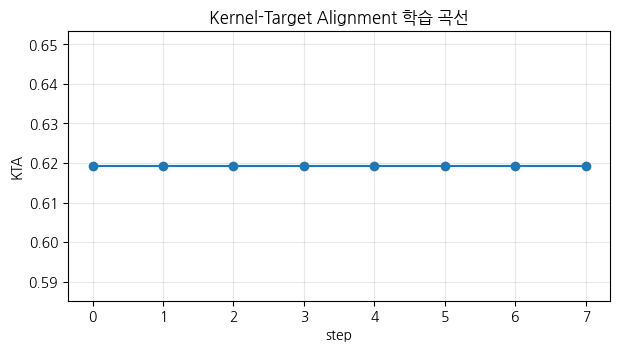

최종 KTA = 0.6193


In [9]:
# 학습 (작은 데이터셋이라 빠름)
opt = qml.AdamOptimizer(0.1)
history_kta = []
for step in range(8):
    params_kta, loss = opt.step_and_cost(
        lambda p: alignment_loss(p, X_kta, y_kta), params_kta
    )
    history_kta.append(-loss)  # KTA는 -loss

plt.figure(figsize=(7, 3.5))
plt.plot(history_kta, 'o-')
plt.xlabel('step'); plt.ylabel('KTA')
plt.title('Kernel-Target Alignment 학습 곡선')
plt.grid(alpha=0.3); plt.show()
print(f'최종 KTA = {history_kta[-1]:.4f}')

In [10]:
# 학습된 커널로 SVM 분류 (학습용 10개 샘플과 일치하는 레이블 사용)
y_kta_label = y_tr[:10]
K_train_kta = np.array([[float(kernel_circuit_kta(x1, x2, params_kta))
                          for x2 in X_kta] for x1 in X_kta])
X_te_kta = X_te[:, :n_q_kta]
K_test_kta = np.array([[float(kernel_circuit_kta(x1, x2, params_kta))
                         for x2 in X_kta] for x1 in X_te_kta])

svm_kta = SVC(kernel='precomputed').fit(K_train_kta, y_kta_label)
acc_kta = svm_kta.score(K_test_kta, y_te)
print(f'학습형 커널 + SVM 테스트 정확도: {acc_kta:.3f}')
print(f'(비교) 고정 커널 + SVM 정확도: {acc_te:.3f}')

학습형 커널 + SVM 테스트 정확도: 1.000
(비교) 고정 커널 + SVM 정확도: 1.000


**관찰.** Iris setosa-versicolor가 워낙 쉬워 두 정확도 모두 높지만, 어려운 데이터셋(예: nested moons, checkerboard)에서는 KTA로 학습된 커널이 일관되게 더 좋다. 핵심 메시지는 **"양자 커널도 학습 가능한 객체"**라는 점이다.

## 9.6 정리
- Quantum kernel은 U(x_i)†U(x_j) 회로의 |0⟩ 측정 확률이다.
- scikit-learn의 `kernel='precomputed'`로 양자 커널을 자유롭게 결합할 수 있다.
- **KTA**를 손실로 임베딩 회로 파라미터를 학습하면 데이터에 맞춰진 커널이 만들어진다.
- VQC와 비교하면, kernel 방식은 회로 평가 횟수가 더 적게 들 수 있는 장점이 있다.